# CaSR results vs HRDPS results in Mar. 2023 vs Observation


## SoG Central and SoG East Grid Index

For `SoG Central`:
    LATITUDE:     49.040026                         / Latitude North
    LONGITUDE:  -123.425513                         / Longitude East

For `SoG East`:
    LATITUDE:     49.042960                         / Latitude North
    LONGITUDE:  -123.316552                         / Longitude East



In [13]:
# locate the grid numbers for the 2 locations

import xarray as xr

# hrdps results paths
hrdps_u_path = "/results2/SalishSea/nowcast-green.202111/01mar23/SalishSea_1h_20230301_20230301_grid_U.nc"
hrdps_v_path = "/results2/SalishSea/nowcast-green.202111/01mar23/SalishSea_1h_20230301_20230301_grid_V.nc"


# load 

ds_hrdps_u=xr.open_dataset(hrdps_u_path)
ds_hrdps_v=xr.open_dataset(hrdps_v_path)

print(ds_hrdps_u)

<xarray.Dataset> Size: 1GB
Dimensions:               (y: 898, x: 398, nvertex: 4, depthu: 40,
                           axis_nbounds: 2, time_counter: 24)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * depthu                (depthu) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 192B ...
  * time_counter          (time_counter) datetime64[ns] 192B 2023-03-01T00:30...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_lon            (y, x, nvertex) float32 6MB ...
    bounds_lat            (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    depthu_bounds         (depthu, axis_nbounds) float32 320B ...
    vozocrtx              (time_counter, depthu, y, x) float32 1GB ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 384B ...
    time_counter_bounds   (time_counter, axis_nbounds)

In [ ]:
import numpy as np
import xarray as xr

# load U grid
ds = xr.open_dataset(hrdps_u_path)

lat = ds.nav_lat.values
lon = ds.nav_lon.values

locations = {
    "SoG Central": (49.040026, -123.425513),
    "SoG East":    (49.042960, -123.316552),
}

for name, (target_lat, target_lon) in locations.items():

    # simple squared distance in lat/lon space
    dist2 = (lat - target_lat)**2 + (lon - target_lon)**2

    # find nearest grid point
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    print(name)
    print("  y index =", j)
    print("  x index =", i)
    print("  grid lat =", lat[j, i])
    print("  grid lon =", lon[j, i])
    print()

In [ ]:
import numpy as np
import xarray as xr

# load U grid
ds = xr.open_dataset(hrdps_v_path)

lat = ds.nav_lat.values
lon = ds.nav_lon.values

locations = {
    "SoG Central": (49.040026, -123.425513),
    "SoG East":    (49.042960, -123.316552),
}

for name, (target_lat, target_lon) in locations.items():

    # simple squared distance in lat/lon space
    dist2 = (lat - target_lat)**2 + (lon - target_lon)**2

    # find nearest grid point
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    print(name)
    print("  y index =", j)
    print("  x index =", i)
    print("  grid lat =", lat[j, i])
    print("  grid lon =", lon[j, i])
    print()



For `SoG Central`:
    U Grid: y index = 424, x index = 266
    V Grid: y index = 423, x index = 266

For `SoG East`:
    U Grid: y index = 416, x index = 282
    V Grid: y index = 416, x index = 283


## Surface Velocity at SoG central/east in mar2023

### Load Data

In [8]:
# Observation
import xarray as xr
path_central_observation_adcp='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Data_ONC/Mar2023/StraitofGeorgiaCentral_ADCP.nc'
path_east_observation_adcp='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Data_ONC/Mar2023/StraitofGeorgiaEast_ADCP.nc'


ds_central_adcp=xr.open_dataset(path_central_observation_adcp)
ds_east_adcp=xr.open_dataset(path_east_observation_adcp)

# print(ds_central_adcp)

*Would be best to chose depth=0*

In [9]:
u_obs_central=ds_central_adcp.sel(depth=5, method='nearest')['u'] # unit: m/s, UTC time
v_obs_central=ds_central_adcp.sel(depth=5, method='nearest')['v']

u_obs_east=ds_east_adcp.sel(depth=5, method='nearest')['u']
v_obs_east=ds_east_adcp.sel(depth=5, method='nearest')['v']


In [13]:
print(u_obs_east['depth'].values)

5.632545310007345


In [10]:
# save to CSV

import os
import pandas as pd

# Output directory
output_dir = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Test_results_comparison/Data_SoG_Central_and_East'
os.makedirs(output_dir, exist_ok=True)

# Central
df_central = pd.DataFrame({
    'time_central': u_obs_central['time'].values,
    'u_obs_central': u_obs_central.values,
    'v_obs_central': v_obs_central.values,
})

# East
df_east = pd.DataFrame({
    'time_east': u_obs_east['time'].values,
    'u_obs_east': u_obs_east.values,
    'v_obs_east': v_obs_east.values,
})

# 按序号拼接
df_obs = pd.concat(
    [
        df_central.reset_index(drop=True),
        df_east.reset_index(drop=True)
    ],
    axis=1
)

# 加一个序号列
df_obs.index.name = 'index'
df_obs = df_obs.reset_index()

# Save
output_csv = os.path.join(
    output_dir,
    'SoG_Central_and_East_surface_ADCP.csv'
)

df_obs.to_csv(output_csv, index=False)

print(f'Saved to: {output_csv}')
print(df_obs.head())

Saved to: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Test_results_comparison/Data_SoG_Central_and_East/SoG_Central_and_East_surface_ADCP.csv
   index                  time_central  u_obs_central  v_obs_central  \
0      0 2023-03-01 00:30:00.000003328       0.996254      -0.697431   
1      1 2023-03-01 01:30:00.000000000       0.772214      -0.773857   
2      2 2023-03-01 02:30:00.000006656       0.305263      -0.101950   
3      3 2023-03-01 03:30:00.000003328      -0.131167      -0.258663   
4      4 2023-03-01 04:30:00.000000000      -0.973691      -0.162189   

                      time_east  u_obs_east  v_obs_east  
0 2023-03-17 22:30:00.000000000         NaN         NaN  
1 2023-03-17 23:29:59.999996672    0.123425   -0.139755  
2 2023-03-18 00:30:00.000003328    0.290001   -0.258737  
3 2023-03-18 01:30:00.000000000    0.446648   -0.782784  
4 2023-03-18 02:30:00.000006656    0.407420   -0.743917  


In [ ]:
# load data 

import xarray as xr

path_casr_u = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
path_casr_v = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'

ds_casr_u = xr.open_dataset(path_casr_u)
ds_casr_v = xr.open_dataset(path_casr_v)

# U: first take surface, then load the two requested points together
u_surface = ds_casr_u['vozocrtx'].isel(depthu=0)

u_points = u_surface.isel(
    y=xr.DataArray([424, 416], dims='station'),
    x=xr.DataArray([266, 282], dims='station')
).load()

u_casr_central = u_points.isel(station=0)
u_casr_east = u_points.isel(station=1)


# V: same idea
v_surface = ds_casr_v['vomecrty'].isel(depthv=0)

v_points = v_surface.isel(
    y=xr.DataArray([423, 416], dims='station'),
    x=xr.DataArray([266, 283], dims='station')
).load()

v_casr_central = v_points.isel(station=0)
v_casr_east = v_points.isel(station=1)

ds_casr_u.close()
ds_casr_v.close()


In [1]:
# save to csv

import os
import xarray as xr
import pandas as pd

# ============================================================
# Paths
# ============================================================

path_casr_u = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
path_casr_v = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'

output_dir = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Test_results_comparison/Data_SoG_Central_and_East'
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(
    output_dir,
    'SoG_Central_and_East_CaSR.csv'
)

# ============================================================
# Open datasets
# ============================================================

ds_casr_u = xr.open_dataset(path_casr_u)
ds_casr_v = xr.open_dataset(path_casr_v)

# ============================================================
# Read U points together
#
# Central: y=424, x=266
# East:    y=416, x=282
# ============================================================

u_points = (
    ds_casr_u['vozocrtx']
    .isel(
        depthu=0,
        y=xr.DataArray([424, 416], dims='station'),
        x=xr.DataArray([266, 282], dims='station')
    )
    .load()
)

u_casr_central = u_points.isel(station=0)
u_casr_east = u_points.isel(station=1)

# ============================================================
# Read V points together
#
# Central: y=423, x=266
# East:    y=416, x=283
# ============================================================

v_points = (
    ds_casr_v['vomecrty']
    .isel(
        depthv=0,
        y=xr.DataArray([423, 416], dims='station'),
        x=xr.DataArray([266, 283], dims='station')
    )
    .load()
)

v_casr_central = v_points.isel(station=0)
v_casr_east = v_points.isel(station=1)

# ============================================================
# Close NetCDF files
# ============================================================

ds_casr_u.close()
ds_casr_v.close()

# ============================================================
# Convert to DataFrame
# ============================================================

df_central = pd.DataFrame({
    'time_casr_central': u_casr_central['time_counter'].values,
    'u_casr_central': u_casr_central.values,
    'v_casr_central': v_casr_central.values,
})

df_east = pd.DataFrame({
    'time_casr_east': u_casr_east['time_counter'].values,
    'u_casr_east': u_casr_east.values,
    'v_casr_east': v_casr_east.values,
})

# ============================================================
# Combine by index
# ============================================================

df_casr = pd.concat(
    [
        df_central.reset_index(drop=True),
        df_east.reset_index(drop=True)
    ],
    axis=1
)

df_casr.index.name = 'index'
df_casr = df_casr.reset_index()

# ============================================================
# Save CSV
# ============================================================

df_casr.to_csv(output_csv, index=False)

print(f'Saved to: {output_csv}')
print(f'Shape: {df_casr.shape}')
print(df_casr.head())

Saved to: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Test_results_comparison/Data_SoG_Central_and_East/SoG_Central_and_East_CaSR.csv
Shape: (744, 7)
   index   time_casr_central  u_casr_central  v_casr_central  \
0      0 2023-03-01 00:30:00       -0.048048       -0.266652   
1      1 2023-03-01 01:30:00       -0.082660       -0.241258   
2      2 2023-03-01 02:30:00       -0.048010       -0.151417   
3      3 2023-03-01 03:30:00        0.054148       -0.089239   
4      4 2023-03-01 04:30:00        0.021206       -0.056146   

       time_casr_east  u_casr_east  v_casr_east  
0 2023-03-01 00:30:00    -0.034954    -0.299605  
1 2023-03-01 01:30:00     0.039294    -0.434806  
2 2023-03-01 02:30:00     0.018228    -0.420586  
3 2023-03-01 03:30:00     0.022548    -0.263240  
4 2023-03-01 04:30:00    -0.005189    -0.203706  


In [2]:
# HRDPS Output

from pathlib import Path
import xarray as xr
from dask.distributed import Client

# Use multiple CPU cores
client = Client(n_workers=8, threads_per_worker=1)
client

path_base_hrdps=Path("/results2/SalishSea/nowcast-green.202111")

filelist_hrdps_u=sorted(path_base_hrdps.glob("*mar23/SalishSea_1h_202303*_202303*_grid_U.nc"))
filelist_hrdps_v=sorted(path_base_hrdps.glob("*mar23/SalishSea_1h_202303*_202303*_grid_V.nc"))

ds_hrdps_u=xr.open_mfdataset(filelist_hrdps_u)
ds_hrdps_v=xr.open_mfdataset(filelist_hrdps_v)


u_hrdps_central=ds_hrdps_u['vozocrtx'].isel(y=424,x=266,depthu=0)
v_hrdps_central=ds_hrdps_v['vomecrty'].isel(y=423,x=266,depthv=0)

u_hrdps_east=ds_hrdps_u['vozocrtx'].isel(y=416,x=282,depthu=0)
v_hrdps_east=ds_hrdps_v['vomecrty'].isel(y=416,x=283,depthv=0)

# Actually read selected data into memory
from dask import compute

(
    u_hrdps_central,
    v_hrdps_central,
    u_hrdps_east,
    v_hrdps_east,
) = compute(
    u_hrdps_central,
    v_hrdps_central,
    u_hrdps_east,
    v_hrdps_east,
)

# Close files

ds_hrdps_u.close()
ds_hrdps_v.close()

# Extra check
# print(len(filelist_hrdps_u), len(filelist_hrdps_v))

# print(u_hrdps_central.sizes)
# print(v_hrdps_central.sizes)

/tmp/ipykernel_1444800/3712061829.py:16: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps_u=xr.open_mfdataset(filelist_hrdps_u)
/tmp/ipykernel_1444800/3712061829.py:17: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps_v=xr.open_mfdataset(filelist_hrdps_v)
2026-08-13 14:16:28,920 - distributed.worker

In [3]:
import os
import pandas as pd

# ============================================================
# Output path
# ============================================================

output_dir = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Test_results_comparison/Data_SoG_Central_and_East'
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(
    output_dir,
    'SoG_Central_and_East_HRDPS.csv'
)

# ============================================================
# Convert to DataFrame
# ============================================================

df_hrdps_central = pd.DataFrame({
    'time_hrdps_central': u_hrdps_central['time_counter'].values,
    'u_hrdps_central': u_hrdps_central.values,
    'v_hrdps_central': v_hrdps_central.values,
})

df_hrdps_east = pd.DataFrame({
    'time_hrdps_east': u_hrdps_east['time_counter'].values,
    'u_hrdps_east': u_hrdps_east.values,
    'v_hrdps_east': v_hrdps_east.values,
})

# ============================================================
# Combine by index
# ============================================================

df_hrdps = pd.concat(
    [
        df_hrdps_central.reset_index(drop=True),
        df_hrdps_east.reset_index(drop=True)
    ],
    axis=1
)

# Add index column
df_hrdps.index.name = 'index'
df_hrdps = df_hrdps.reset_index()

# ============================================================
# Save CSV
# ============================================================

df_hrdps.to_csv(output_csv, index=False)

print(f'Saved to: {output_csv}')
print(f'Shape: {df_hrdps.shape}')
print(df_hrdps.head())

Saved to: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Test_results_comparison/Data_SoG_Central_and_East/SoG_Central_and_East_HRDPS.csv
Shape: (744, 7)
   index  time_hrdps_central  u_hrdps_central  v_hrdps_central  \
0      0 2023-03-01 00:30:00        -0.055434        -0.257327   
1      1 2023-03-01 01:30:00        -0.098497        -0.200856   
2      2 2023-03-01 02:30:00        -0.057663        -0.075566   
3      3 2023-03-01 03:30:00         0.051924        -0.003684   
4      4 2023-03-01 04:30:00        -0.121551         0.090998   

      time_hrdps_east  u_hrdps_east  v_hrdps_east  
0 2023-03-01 00:30:00     -0.044552     -0.252339  
1 2023-03-01 01:30:00      0.035880     -0.271133  
2 2023-03-01 02:30:00      0.015662     -0.199318  
3 2023-03-01 03:30:00     -0.006237     -0.085122  
4 2023-03-01 04:30:00     -0.048286      0.087125  


### Check data

In [17]:
# check the data

print(u_obs_central)

<xarray.DataArray 'u' (time: 720)> Size: 6kB
[720 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 6kB 2023-03-01T00:30:00.000003328 ... 2023...
    depth    float64 8B -0.03853
Attributes:
    sdn_parameter_name:  eastward_sea_water_velocity
    long_name:           eastward sea water velocity
    units:               m s-1


In [18]:
print(u_hrdps_central)

<xarray.DataArray 'vozocrtx' (time_counter: 744)> Size: 3kB
dask.array<getitem, shape=(744,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
    nav_lat        float32 4B dask.array<chunksize=(), meta=np.ndarray>
    nav_lon        float32 4B dask.array<chunksize=(), meta=np.ndarray>
    depthu         float32 4B 0.5
    time_centered  (time_counter) datetime64[ns] 6kB dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter   (time_counter) datetime64[ns] 6kB 2023-03-01T00:30:00 ... ...
Attributes:
    standard_name:       sea_water_x_velocity
    long_name:           Ocean Current Along x-Axis
    units:               m s-1
    online_operation:    average
    interval_operation:  40 s
    interval_write:      1 h
    cell_methods:        time: mean (interval: 40 s)
    cell_measures:       area: area


In [19]:
print(u_casr_central)

<xarray.DataArray 'vozocrtx' (time_counter: 744)> Size: 3kB
[744 values with dtype=float32]
Coordinates:
    nav_lat        float32 4B ...
    nav_lon        float32 4B ...
    depthu         float32 4B 0.5
    time_centered  (time_counter) datetime64[ns] 6kB ...
  * time_counter   (time_counter) datetime64[ns] 6kB 2023-03-01T00:30:00 ... ...
Attributes:
    standard_name:       sea_water_x_velocity
    long_name:           Ocean Current Along x-Axis
    units:               m s-1
    online_operation:    average
    interval_operation:  40 s
    interval_write:      1 h
    cell_methods:        time: mean (interval: 40 s)
    cell_measures:       area: area


### Visualize

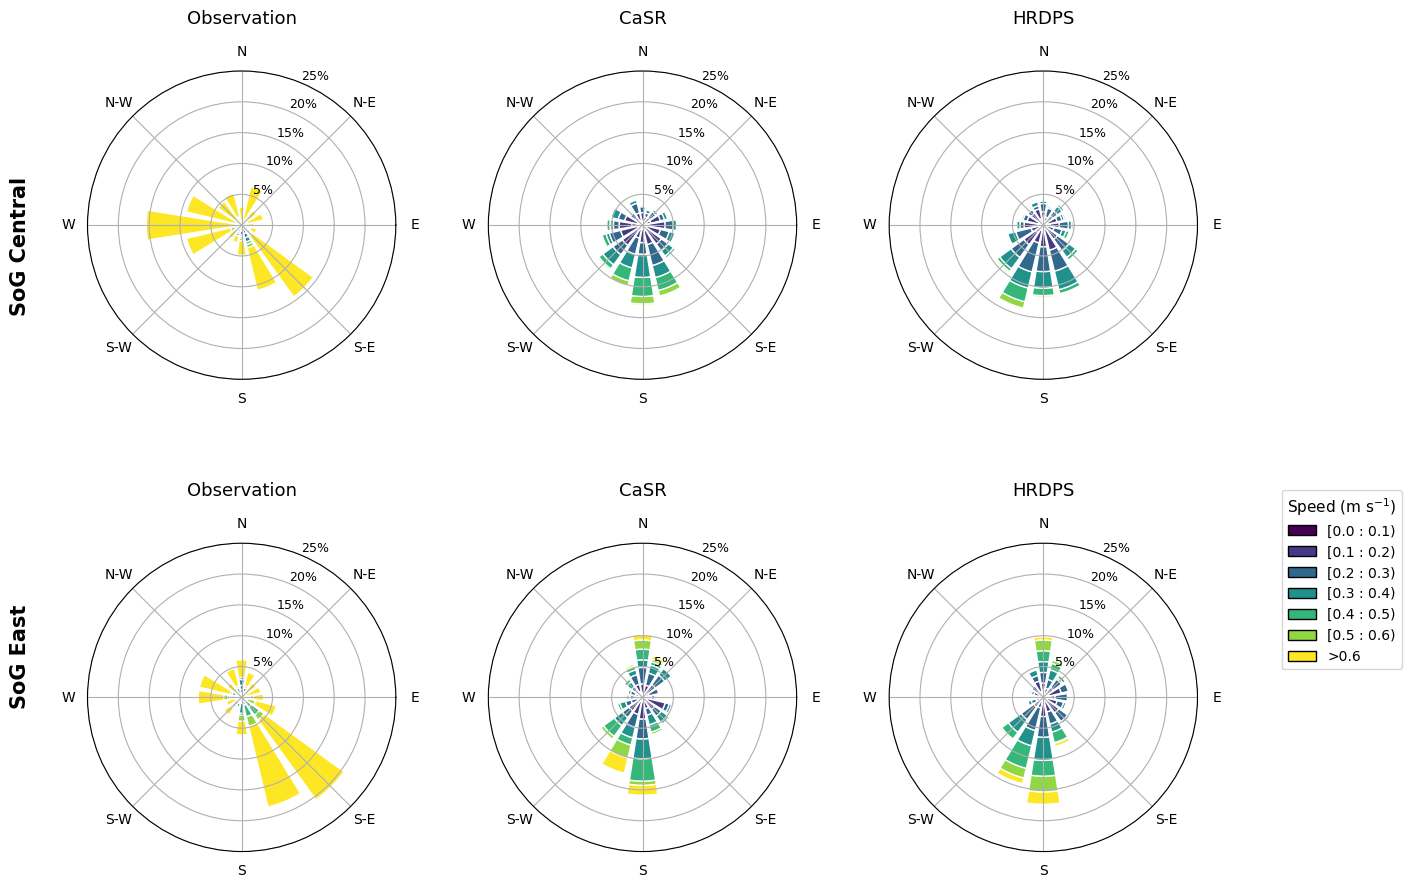

In [18]:
# ============================================================
# Current Rose Comparison: Observation vs CaSR vs HRDPS
# 2 rows x 3 columns
#
# Row 1: SoG Central
# Row 2: SoG East
#
# Column 1: Observation
# Column 2: CaSR
# Column 3: HRDPS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Convert u/v to speed and direction
# ============================================================

def uv_to_speed_direction(u, v):
    """
    Convert eastward (u) and northward (v) velocity
    to speed and direction.

    Direction convention:
        0°   = North
        90°  = East
        180° = South
        270° = West

    Direction indicates where the current is flowing TOWARD.
    """

    u = np.asarray(u, dtype=float).squeeze()
    v = np.asarray(v, dtype=float).squeeze()

    # Remove NaN and inf
    valid = np.isfinite(u) & np.isfinite(v)

    u = u[valid]
    v = v[valid]

    # Current speed
    speed = np.sqrt(u**2 + v**2)

    # Direction: atan2(East, North)
    direction = (
        np.degrees(np.arctan2(u, v)) + 360
    ) % 360

    return speed, direction


# ============================================================
# Plot one current rose
# ============================================================

def plot_rose_on_ax(
    ax,
    u,
    v,
    title,
    bins,
    rmax=25,
    rticks=(5, 10, 15, 20, 25)
):
    """
    Plot one current rose onto an existing WindroseAxes.
    """

    speed, direction = uv_to_speed_direction(u, v)

    ax.bar(
        direction,
        speed,
        bins=bins,
        normed=True,
        opening=0.8,
        edgecolor='white'
    )

    # Panel title
    ax.set_title(
        title,
        fontsize=13,
        pad=15
    )

    # Same radial scale for all panels
    ax.set_ylim(0, rmax)

    ax.set_yticks(rticks)

    ax.set_yticklabels(
        [f'{x}%' for x in rticks],
        fontsize=9
    )

    return ax


# ============================================================
# Data directory
# ============================================================

data_dir = (
    '/home/jqiu/analysis-junqi/'
    'Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/'
    'Test_results_comparison/'
    'Data_SoG_Central_and_East'
)


# ============================================================
# Read CSV files
# ============================================================

df_obs = pd.read_csv(
    os.path.join(
        data_dir,
        'SoG_Central_and_East_surface_ADCP.csv'
    )
)

df_casr = pd.read_csv(
    os.path.join(
        data_dir,
        'SoG_Central_and_East_CaSR.csv'
    )
)

df_hrdps = pd.read_csv(
    os.path.join(
        data_dir,
        'SoG_Central_and_East_HRDPS.csv'
    )
)


# ============================================================
# Speed bins
#
# All 6 panels MUST use the same bins
#
# These produce:
# 0.0-0.1
# 0.1-0.2
# ...
# 0.5-0.6
# >=0.6 m/s
# ============================================================

bins = np.arange(0, 0.7, 0.1)


# ============================================================
# Create figure
# ============================================================

fig = plt.figure(
    figsize=(15, 10)
)


# ============================================================
# Row 1: SoG Central
# ============================================================

ax1 = fig.add_subplot(
    2, 3, 1,
    projection='windrose'
)

plot_rose_on_ax(
    ax1,
    df_obs['u_obs_central'],
    df_obs['v_obs_central'],
    'Observation',
    bins
)


ax2 = fig.add_subplot(
    2, 3, 2,
    projection='windrose'
)

plot_rose_on_ax(
    ax2,
    df_casr['u_casr_central'],
    df_casr['v_casr_central'],
    'CaSR',
    bins
)


ax3 = fig.add_subplot(
    2, 3, 3,
    projection='windrose'
)

plot_rose_on_ax(
    ax3,
    df_hrdps['u_hrdps_central'],
    df_hrdps['v_hrdps_central'],
    'HRDPS',
    bins
)


# ============================================================
# Row 2: SoG East
# ============================================================

ax4 = fig.add_subplot(
    2, 3, 4,
    projection='windrose'
)

plot_rose_on_ax(
    ax4,
    df_obs['u_obs_east'],
    df_obs['v_obs_east'],
    'Observation',
    bins
)


ax5 = fig.add_subplot(
    2, 3, 5,
    projection='windrose'
)

plot_rose_on_ax(
    ax5,
    df_casr['u_casr_east'],
    df_casr['v_casr_east'],
    'CaSR',
    bins
)


ax6 = fig.add_subplot(
    2, 3, 6,
    projection='windrose'
)

plot_rose_on_ax(
    ax6,
    df_hrdps['u_hrdps_east'],
    df_hrdps['v_hrdps_east'],
    'HRDPS',
    bins
)


# ============================================================
# Row labels
# ============================================================

fig.text(
    0.035,
    0.70,
    'SoG Central',
    rotation=90,
    va='center',
    ha='center',
    fontsize=15,
    fontweight='bold'
)

fig.text(
    0.035,
    0.29,
    'SoG East',
    rotation=90,
    va='center',
    ha='center',
    fontsize=15,
    fontweight='bold'
)


# ============================================================
# Shared speed legend
#
# The colors represent CURRENT SPEED.
# The radial axis represents FREQUENCY (%).
# ============================================================

legend = ax3.legend(
    title='Speed (m s$^{-1}$)',
    loc='center left',
    bbox_to_anchor=(1.25, -0.65),
    fontsize=10,
    title_fontsize=11
)





# ============================================================
# Layout
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.82,
    top=0.90,
    bottom=0.07,
    wspace=0.30,
    hspace=0.32
)


# ============================================================
# Show figure
# ============================================================

plt.show()

### Time Series



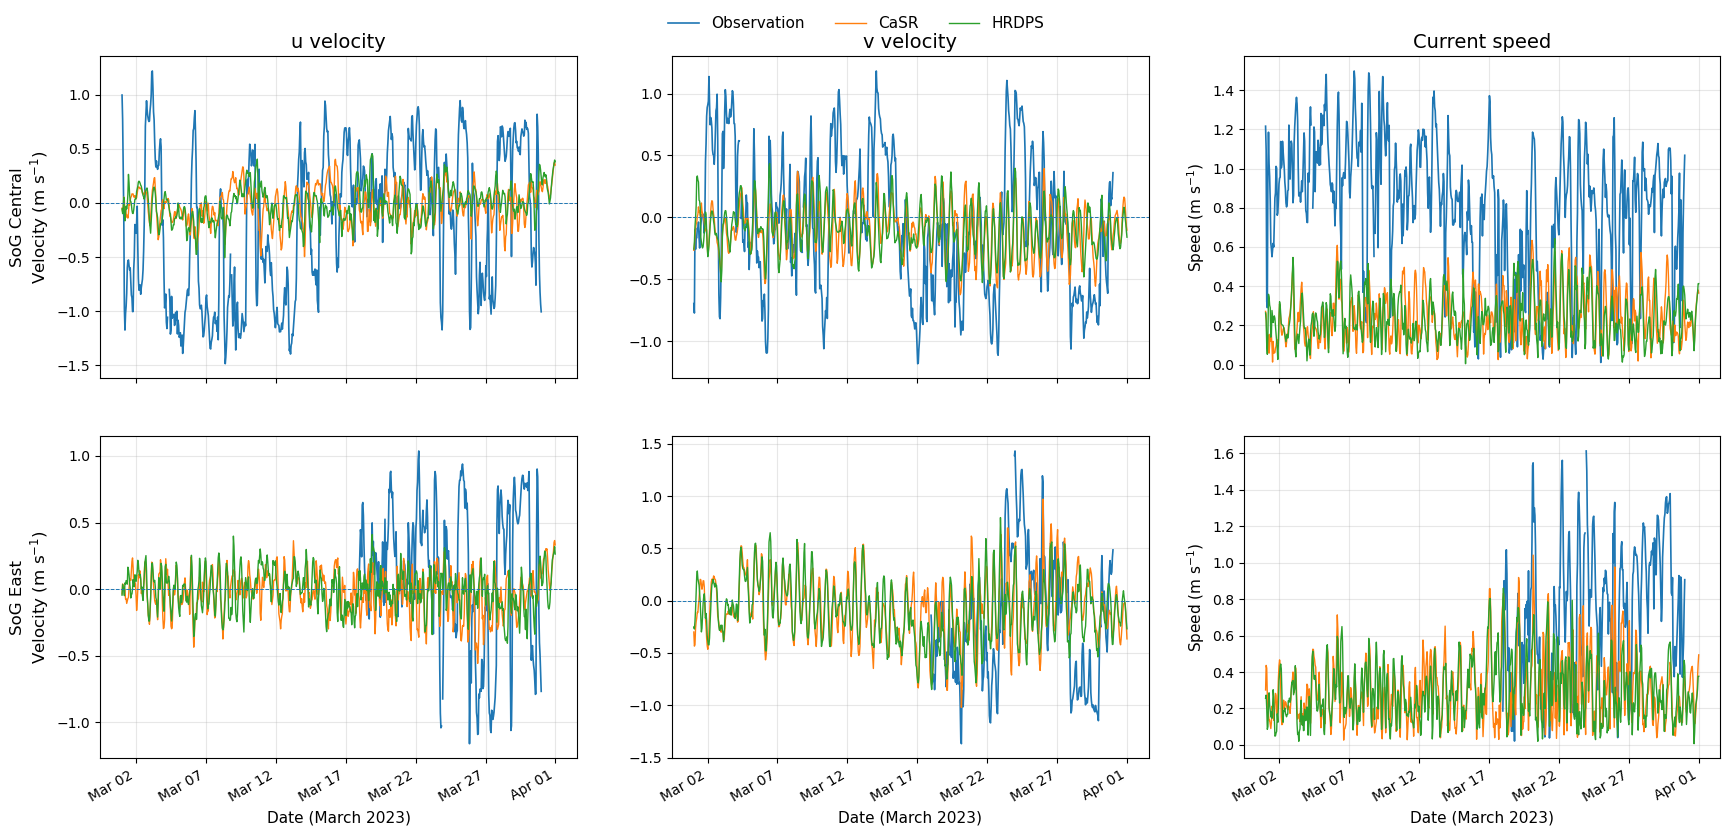

In [20]:
# ============================================================
# Time Series Comparison
#
# Row 1: SoG Central
# Row 2: SoG East
#
# Column 1: u velocity
# Column 2: v velocity
# Column 3: current speed
#
# Lines: Observation / CaSR / HRDPS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# Data directory
# ============================================================

data_dir = (
    '/home/jqiu/analysis-junqi/'
    'Analysis_Atmospheric_Forcing/'
    'Analysis_results_comparison/'
    'Test_results_comparison/'
    'Data_SoG_Central_and_East'
)


# ============================================================
# Read CSV
# ============================================================

df_obs = pd.read_csv(
    os.path.join(
        data_dir,
        'SoG_Central_and_East_surface_ADCP.csv'
    )
)

df_casr = pd.read_csv(
    os.path.join(
        data_dir,
        'SoG_Central_and_East_CaSR.csv'
    )
)

df_hrdps = pd.read_csv(
    os.path.join(
        data_dir,
        'SoG_Central_and_East_HRDPS.csv'
    )
)


# ============================================================
# Convert time columns to datetime
# ============================================================

df_obs['time_central'] = pd.to_datetime(
    df_obs['time_central']
)

df_obs['time_east'] = pd.to_datetime(
    df_obs['time_east']
)


df_casr['time_casr_central'] = pd.to_datetime(
    df_casr['time_casr_central']
)

df_casr['time_casr_east'] = pd.to_datetime(
    df_casr['time_casr_east']
)


df_hrdps['time_hrdps_central'] = pd.to_datetime(
    df_hrdps['time_hrdps_central']
)

df_hrdps['time_hrdps_east'] = pd.to_datetime(
    df_hrdps['time_hrdps_east']
)


# ============================================================
# Calculate current speed
#
# speed = sqrt(u^2 + v^2)
# ============================================================

# Observation
df_obs['speed_obs_central'] = np.sqrt(
    df_obs['u_obs_central']**2
    + df_obs['v_obs_central']**2
)

df_obs['speed_obs_east'] = np.sqrt(
    df_obs['u_obs_east']**2
    + df_obs['v_obs_east']**2
)


# CaSR
df_casr['speed_casr_central'] = np.sqrt(
    df_casr['u_casr_central']**2
    + df_casr['v_casr_central']**2
)

df_casr['speed_casr_east'] = np.sqrt(
    df_casr['u_casr_east']**2
    + df_casr['v_casr_east']**2
)


# HRDPS
df_hrdps['speed_hrdps_central'] = np.sqrt(
    df_hrdps['u_hrdps_central']**2
    + df_hrdps['v_hrdps_central']**2
)

df_hrdps['speed_hrdps_east'] = np.sqrt(
    df_hrdps['u_hrdps_east']**2
    + df_hrdps['v_hrdps_east']**2
)


# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    sharex=True
)


# ============================================================
# CENTRAL
# ============================================================

# ------------------------------------------------------------
# Central u
# ------------------------------------------------------------

axes[0, 0].plot(
    df_obs['time_central'],
    df_obs['u_obs_central'],
    label='Observation',
    linewidth=1.2
)

axes[0, 0].plot(
    df_casr['time_casr_central'],
    df_casr['u_casr_central'],
    label='CaSR',
    linewidth=1.0
)

axes[0, 0].plot(
    df_hrdps['time_hrdps_central'],
    df_hrdps['u_hrdps_central'],
    label='HRDPS',
    linewidth=1.0
)

axes[0, 0].set_title(
    'u velocity',
    fontsize=14
)

axes[0, 0].set_ylabel(
    'SoG Central\nVelocity (m s$^{-1}$)',
    fontsize=12
)

axes[0, 0].axhline(
    0,
    linewidth=0.7,
    linestyle='--'
)


# ------------------------------------------------------------
# Central v
# ------------------------------------------------------------

axes[0, 1].plot(
    df_obs['time_central'],
    df_obs['v_obs_central'],
    label='Observation',
    linewidth=1.2
)

axes[0, 1].plot(
    df_casr['time_casr_central'],
    df_casr['v_casr_central'],
    label='CaSR',
    linewidth=1.0
)

axes[0, 1].plot(
    df_hrdps['time_hrdps_central'],
    df_hrdps['v_hrdps_central'],
    label='HRDPS',
    linewidth=1.0
)

axes[0, 1].set_title(
    'v velocity',
    fontsize=14
)

axes[0, 1].axhline(
    0,
    linewidth=0.7,
    linestyle='--'
)


# ------------------------------------------------------------
# Central speed
# ------------------------------------------------------------

axes[0, 2].plot(
    df_obs['time_central'],
    df_obs['speed_obs_central'],
    label='Observation',
    linewidth=1.2
)

axes[0, 2].plot(
    df_casr['time_casr_central'],
    df_casr['speed_casr_central'],
    label='CaSR',
    linewidth=1.0
)

axes[0, 2].plot(
    df_hrdps['time_hrdps_central'],
    df_hrdps['speed_hrdps_central'],
    label='HRDPS',
    linewidth=1.0
)

axes[0, 2].set_title(
    'Current speed',
    fontsize=14
)

axes[0, 2].set_ylabel(
    'Speed (m s$^{-1}$)',
    fontsize=11
)


# ============================================================
# EAST
# ============================================================

# ------------------------------------------------------------
# East u
# ------------------------------------------------------------

axes[1, 0].plot(
    df_obs['time_east'],
    df_obs['u_obs_east'],
    label='Observation',
    linewidth=1.2
)

axes[1, 0].plot(
    df_casr['time_casr_east'],
    df_casr['u_casr_east'],
    label='CaSR',
    linewidth=1.0
)

axes[1, 0].plot(
    df_hrdps['time_hrdps_east'],
    df_hrdps['u_hrdps_east'],
    label='HRDPS',
    linewidth=1.0
)

axes[1, 0].set_ylabel(
    'SoG East\nVelocity (m s$^{-1}$)',
    fontsize=12
)

axes[1, 0].axhline(
    0,
    linewidth=0.7,
    linestyle='--'
)


# ------------------------------------------------------------
# East v
# ------------------------------------------------------------

axes[1, 1].plot(
    df_obs['time_east'],
    df_obs['v_obs_east'],
    label='Observation',
    linewidth=1.2
)

axes[1, 1].plot(
    df_casr['time_casr_east'],
    df_casr['v_casr_east'],
    label='CaSR',
    linewidth=1.0
)

axes[1, 1].plot(
    df_hrdps['time_hrdps_east'],
    df_hrdps['v_hrdps_east'],
    label='HRDPS',
    linewidth=1.0
)

axes[1, 1].axhline(
    0,
    linewidth=0.7,
    linestyle='--'
)


# ------------------------------------------------------------
# East speed
# ------------------------------------------------------------

axes[1, 2].plot(
    df_obs['time_east'],
    df_obs['speed_obs_east'],
    label='Observation',
    linewidth=1.2
)

axes[1, 2].plot(
    df_casr['time_casr_east'],
    df_casr['speed_casr_east'],
    label='CaSR',
    linewidth=1.0
)

axes[1, 2].plot(
    df_hrdps['time_hrdps_east'],
    df_hrdps['speed_hrdps_east'],
    label='HRDPS',
    linewidth=1.0
)

axes[1, 2].set_ylabel(
    'Speed (m s$^{-1}$)',
    fontsize=11
)


# ============================================================
# Axis formatting
# ============================================================

for ax in axes.flat:

    ax.grid(
        True,
        alpha=0.3
    )

    # Major tick every 5 days
    ax.xaxis.set_major_locator(
        mdates.DayLocator(interval=5)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %d')
    )


# Rotate bottom-row date labels
for ax in axes[1, :]:
    plt.setp(
        ax.get_xticklabels(),
        rotation=30,
        ha='right'
    )

    ax.set_xlabel(
        'Date (March 2023)',
        fontsize=11
    )


# ============================================================
# Shared legend
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    frameon=False,
    fontsize=11
)





# ============================================================
# Layout
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.88,
    bottom=0.10,
    wspace=0.20,
    hspace=0.18
)

plt.show()

## Velocity Scatter Plot

Date       : 20230301
CaSR index : 12
HRDPS index: 12
CaSR time  : 2023-03-01T12:30:00.000000000
HRDPS time : 2023-03-01T12:30:00.000000000
Valid N    : 171030
RMSE       : 0.0416 m/s
Date       : 20230315
CaSR index : 348
HRDPS index: 12
CaSR time  : 2023-03-15T12:30:00.000000000
HRDPS time : 2023-03-15T12:30:00.000000000
Valid N    : 171030
RMSE       : 0.0554 m/s
Date       : 20230331
CaSR index : 732
HRDPS index: 12
CaSR time  : 2023-03-31T12:30:00.000000000
HRDPS time : 2023-03-31T12:30:00.000000000
Valid N    : 171030
RMSE       : 0.0524 m/s


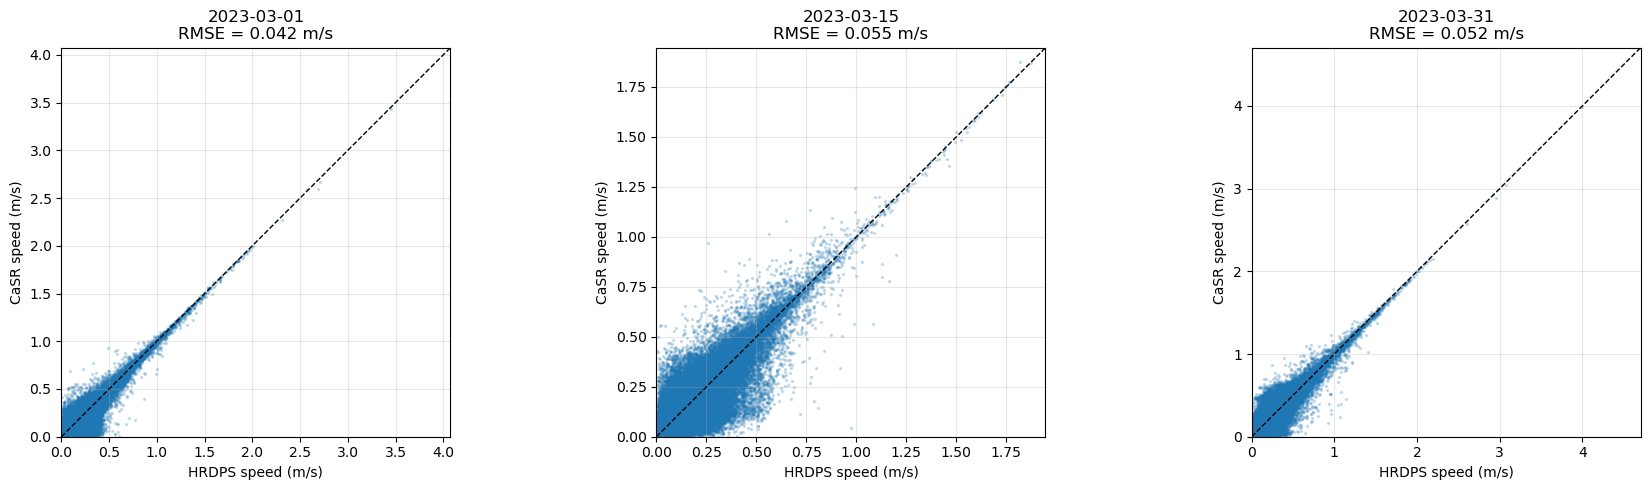


RMSE summary:
20230301: 0.0416 m/s
20230315: 0.0554 m/s
20230331: 0.0524 m/s

Mean RMSE = 0.0498 m/s


In [21]:
# Velocity scatter plot 

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CaSR: whole month
# ============================================================
path_casr_u = (
    '/ocean/jqiu/results/CaSR/00mar23/'
    'SalishSea_1h_20230301_20230331_grid_U.nc'
)

path_casr_v = (
    '/ocean/jqiu/results/CaSR/00mar23/'
    'SalishSea_1h_20230301_20230331_grid_V.nc'
)

casr_u_ds = xr.open_dataset(path_casr_u)
casr_v_ds = xr.open_dataset(path_casr_v)


# ============================================================
# Choose 3 days
# Here we use 12:30 on each day
# daily time index = 12
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230331",
]

# March day numbers
day_numbers = [1, 15, 31]

# same hour for all three days
hour_idx = 12

depth_idx = 0


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rmses = []

for ax, date_str, day_num in zip(axes, days, day_numbers):

    # ========================================================
    # HRDPS daily files
    # ========================================================
    hrdps_u_path = (
        f"/results2/SalishSea/nowcast-green.202111/"
        f"{day_num:02d}mar23/"
        f"SalishSea_1h_{date_str}_{date_str}_grid_U.nc"
    )

    hrdps_v_path = (
        f"/results2/SalishSea/nowcast-green.202111/"
        f"{day_num:02d}mar23/"
        f"SalishSea_1h_{date_str}_{date_str}_grid_V.nc"
    )

    hrdps_u_ds = xr.open_dataset(hrdps_u_path)
    hrdps_v_ds = xr.open_dataset(hrdps_v_path)


    # ========================================================
    # CaSR monthly-file index
    #
    # March 1, 12:30  -> 12
    # March 15, 12:30 -> 14*24 + 12 = 348
    # March 31, 12:30 -> 30*24 + 12 = 732
    # ========================================================
    casr_tidx = (day_num - 1) * 24 + hour_idx

    # HRDPS is one file per day
    hrdps_tidx = hour_idx


    # ========================================================
    # CaSR U/V
    # ========================================================
    casr_u = casr_u_ds['vozocrtx'].isel(
        time_counter=casr_tidx,
        depthu=depth_idx
    ).values

    casr_v = casr_v_ds['vomecrty'].isel(
        time_counter=casr_tidx,
        depthv=depth_idx
    ).values

    casr_speed = np.sqrt(casr_u**2 + casr_v**2)


    # ========================================================
    # HRDPS U/V
    # ========================================================
    hrdps_u = hrdps_u_ds['vozocrtx'].isel(
        time_counter=hrdps_tidx,
        depthu=depth_idx
    ).values

    hrdps_v = hrdps_v_ds['vomecrty'].isel(
        time_counter=hrdps_tidx,
        depthv=depth_idx
    ).values

    hrdps_speed = np.sqrt(hrdps_u**2 + hrdps_v**2)


    # ========================================================
    # Valid ocean points
    # ========================================================
    mask = (
        np.isfinite(casr_speed) &
        np.isfinite(hrdps_speed)
    )

    x = hrdps_speed[mask]
    y = casr_speed[mask]


    # ========================================================
    # RMSE of speed
    # ========================================================
    rmse = np.sqrt(np.mean((y - x)**2))
    rmses.append(rmse)


    # actual time for checking
    casr_time = casr_u_ds.time_counter.isel(
        time_counter=casr_tidx
    ).values

    hrdps_time = hrdps_u_ds.time_counter.isel(
        time_counter=hrdps_tidx
    ).values

    print("=" * 50)
    print(f"Date       : {date_str}")
    print(f"CaSR index : {casr_tidx}")
    print(f"HRDPS index: {hrdps_tidx}")
    print(f"CaSR time  : {casr_time}")
    print(f"HRDPS time : {hrdps_time}")
    print(f"Valid N    : {len(x)}")
    print(f"RMSE       : {rmse:.4f} m/s")


    # ========================================================
    # Scatter
    # ========================================================
    ax.scatter(
        x,
        y,
        s=2,
        alpha=0.2
    )

    # common range
    vmax = max(np.nanmax(x), np.nanmax(y))

    # 1:1 line
    ax.plot(
        [0, vmax],
        [0, vmax],
        'k--',
        lw=1
    )

    ax.set_xlim(0, vmax)
    ax.set_ylim(0, vmax)

    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel('HRDPS speed (m/s)')
    ax.set_ylabel('CaSR speed (m/s)')

    ax.set_title(
        f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}\n'
        f'RMSE = {rmse:.3f} m/s'
    )

    ax.grid(alpha=0.3)

    # close daily HRDPS files
    hrdps_u_ds.close()
    hrdps_v_ds.close()


plt.tight_layout()
plt.show()


# ============================================================
# Summary
# ============================================================
print("\nRMSE summary:")
for date_str, rmse in zip(days, rmses):
    print(f"{date_str}: {rmse:.4f} m/s")

print(f"\nMean RMSE = {np.mean(rmses):.4f} m/s")


casr_u_ds.close()
casr_v_ds.close()

## SST Scatter Plot



Date        : 20230301
CaSR index  : 12
HRDPS index : 12
CaSR time   : 2023-03-01T12:30:00.000000000
HRDPS time  : 2023-03-01T12:30:00.000000000
Valid N     : 171030
SST RMSE    : 0.1605 °C
Date        : 20230315
CaSR index  : 348
HRDPS index : 12
CaSR time   : 2023-03-15T12:30:00.000000000
HRDPS time  : 2023-03-15T12:30:00.000000000
Valid N     : 171030
SST RMSE    : 0.2268 °C
Date        : 20230331
CaSR index  : 732
HRDPS index : 12
CaSR time   : 2023-03-31T12:30:00.000000000
HRDPS time  : 2023-03-31T12:30:00.000000000
Valid N     : 171030
SST RMSE    : 0.2956 °C


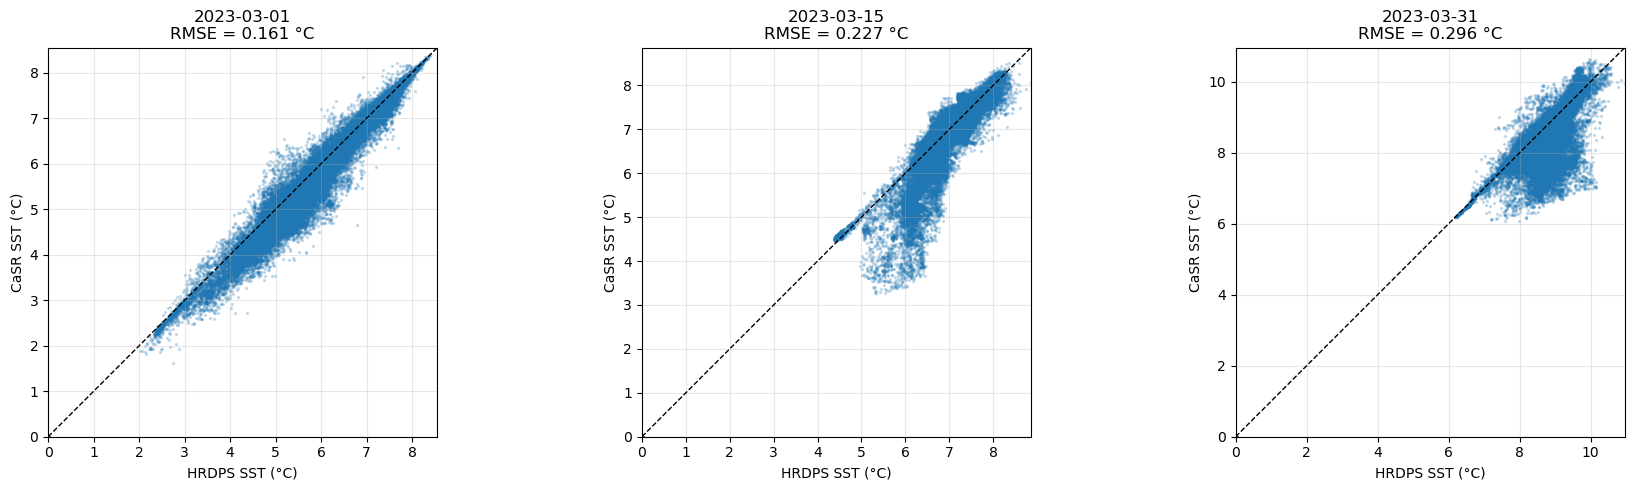


SST RMSE summary:
20230301: 0.1605 °C
20230315: 0.2268 °C
20230331: 0.2956 °C

Mean RMSE = 0.2276 °C


In [22]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CaSR T file: whole month
# ============================================================
path_casr_t = (
    '/ocean/jqiu/results/CaSR/00mar23/'
    'SalishSea_1h_20230301_20230331_grid_T.nc'
)

casr_t_ds = xr.open_dataset(path_casr_t)


# ============================================================
# Choose 3 days
# all use 12:30 -> daily time index = 12
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230331",
]

day_numbers = [1, 15, 31]

hour_idx = 12
depth_idx = 0


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rmses = []

for ax, date_str, day_num in zip(axes, days, day_numbers):

    # ========================================================
    # HRDPS daily T file
    # ========================================================
    hrdps_t_path = (
        f"/results2/SalishSea/nowcast-green.202111/"
        f"{day_num:02d}mar23/"
        f"SalishSea_1h_{date_str}_{date_str}_grid_T.nc"
    )

    hrdps_t_ds = xr.open_dataset(hrdps_t_path)


    # ========================================================
    # Time indices
    # ========================================================
    # CaSR is one monthly file
    casr_tidx = (day_num - 1) * 24 + hour_idx

    # HRDPS is one daily file
    hrdps_tidx = hour_idx


    # ========================================================
    # Sea surface temperature
    # first deptht level
    # ========================================================
    casr_sst = casr_t_ds['votemper'].isel(
        time_counter=casr_tidx,
        deptht=depth_idx
    ).values

    hrdps_sst = hrdps_t_ds['votemper'].isel(
        time_counter=hrdps_tidx,
        deptht=depth_idx
    ).values


    # ========================================================
    # Valid points
    # ========================================================
    mask = (
        np.isfinite(casr_sst) &
        np.isfinite(hrdps_sst)
    )

    x = hrdps_sst[mask]
    y = casr_sst[mask]


    # ========================================================
    # RMSE
    # ========================================================
    rmse = np.sqrt(np.mean((y - x) ** 2))
    rmses.append(rmse)


    # ========================================================
    # Actual times for checking
    # ========================================================
    casr_time = casr_t_ds.time_counter.isel(
        time_counter=casr_tidx
    ).values

    hrdps_time = hrdps_t_ds.time_counter.isel(
        time_counter=hrdps_tidx
    ).values


    print("=" * 50)
    print(f"Date        : {date_str}")
    print(f"CaSR index  : {casr_tidx}")
    print(f"HRDPS index : {hrdps_tidx}")
    print(f"CaSR time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"Valid N     : {len(x)}")
    print(f"SST RMSE    : {rmse:.4f} °C")


    # ========================================================
    # Scatter
    # ========================================================
    ax.scatter(
        x,
        y,
        s=2,
        alpha=0.2
    )

    # same axis range for x/y
    vmin = min(np.nanmin(x), np.nanmin(y))
    vmax = max(np.nanmax(x), np.nanmax(y))

    # 1:1 line
    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        'k--',
        lw=1
    )

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel('HRDPS SST (°C)')
    ax.set_ylabel('CaSR SST (°C)')

    ax.set_title(
        f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}\n'
        f'RMSE = {rmse:.3f} °C'
    )

    ax.grid(alpha=0.3)

    hrdps_t_ds.close()


plt.tight_layout()
plt.show()


# ============================================================
# RMSE summary
# ============================================================
print("\nSST RMSE summary:")

for date_str, rmse in zip(days, rmses):
    print(f"{date_str}: {rmse:.4f} °C")

print(f"\nMean RMSE = {np.mean(rmses):.4f} °C")


casr_t_ds.close()